In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
%pip install numpy pandas matplotlib scikit-learn pillow tqdm kagglehub

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/10.0 MB 15.1 MB/s eta 0:00:01
   ----------------- ---------------------- 4.5/10.0 MB 11.7 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/10.0 MB 10.9 MB/s eta 0:00:01
   ---------------------------------- ----- 8.7/10.0 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 10.0 MB/s  0:00:01
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --------- ------------------------------ 2.1/9.3 MB 9.0 MB/s eta 0:00:01
   ------------ --------------------------- 2.9/9.3 MB 7.3 MB/s eta 0:00:01
   ---------------- ----------------------- 3.9/9.3 MB 6.2 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.3 MB 7.0 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 7.5 MB/s  0:00:01
   -----------------

In [3]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
Torchvision: 0.21.0+cu124
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


CIFAKE

In [4]:
import kagglehub

path = kagglehub.dataset_download(
    "birdy654/cifake-real-and-ai-generated-synthetic-images"
)

print("Dataset downloaded to:")
print(path)

100%|██████████| 105M/105M [00:06<00:00, 18.1MB/s] 

Extracting files...


Dataset downloaded to:
C:\Users\kaise\.cache\kagglehub\datasets\birdy654\cifake-real-and-ai-generated-synthetic-images\versions\3


In [5]:
import os

print(os.listdir(path))

['test', 'train']


In [6]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")

    if level < 2:
        for file in files[:3]:
            print(indent + "    " + file)

3/
    test/
        FAKE/
        REAL/
    train/
        FAKE/
        REAL/


In [7]:
import kagglehub

path = kagglehub.dataset_download(
    "birdy654/cifake-real-and-ai-generated-synthetic-images"
)

print(path)

C:\Users\kaise\.cache\kagglehub\datasets\birdy654\cifake-real-and-ai-generated-synthetic-images\versions\3


In [8]:
import os
print(os.listdir(path))

['test', 'train']


In [9]:
from pathlib import Path

train_dir = Path(path) / "train"
test_dir = Path(path) / "test"

print("Training REAL:", len(list((train_dir / "REAL").glob("*"))))
print("Training FAKE:", len(list((train_dir / "FAKE").glob("*"))))

print("Testing REAL:", len(list((test_dir / "REAL").glob("*"))))
print("Testing FAKE:", len(list((test_dir / "FAKE").glob("*"))))

Training REAL: 50000
Training FAKE: 50000
Testing REAL: 10000
Testing FAKE: 10000


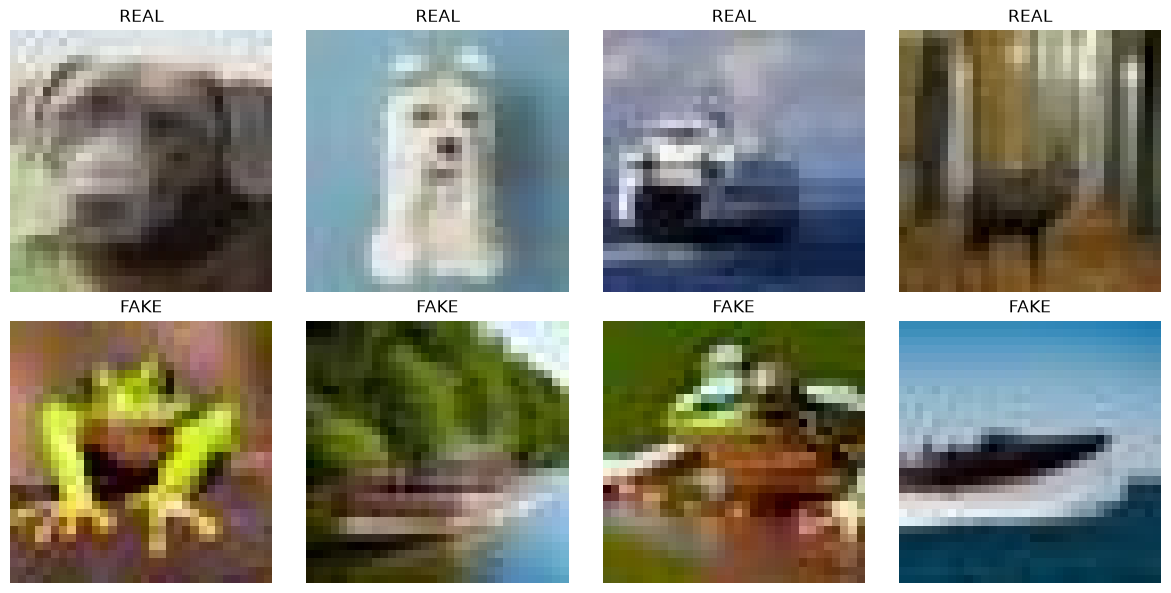

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import random

classes = ["REAL", "FAKE"]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for row, class_name in enumerate(classes):
    image_files = list((train_dir / class_name).glob("*"))
    selected = random.sample(image_files, 4)

    for col, image_file in enumerate(selected):
        img = Image.open(image_file)

        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [11]:
#feed into one group of 64 images

In [12]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# How we prepare every image before giving it to ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load the folders
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

print("Classes:", train_dataset.classes)
print("Class numbers:", train_dataset.class_to_idx)
print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Classes: ['FAKE', 'REAL']
Class numbers: {'FAKE': 0, 'REAL': 1}
Training images: 100000
Testing images: 20000


In [13]:
#create batches

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 1563
Testing batches: 313


In [16]:
#final check

In [15]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])
First 10 labels: tensor([0, 1, 1, 0, 1, 1, 0, 0, 1, 0])


In [17]:
#Load ResNet18

In [18]:
import torch.nn as nn
from torchvision import models

# Load a pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Change the final layer to output 2 classes:
# 0 = FAKE
# 1 = REAL
model.fc = nn.Linear(model.fc.in_features, 2)

# Move the model onto your RTX 4050
model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\kaise/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


Linear(in_features=512, out_features=2, bias=True)


In [ ]:
#Make sure ResNet18 actually runs

In [19]:
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Output shape:", outputs.shape)
print("First image output:", outputs[0])

Output shape: torch.Size([64, 2])
First image output: tensor([ 0.5899, -0.6673], device='cuda:0')


In [20]:
# Freeze all existing ResNet layers
for param in model.parameters():
    param.requires_grad = False

# Allow only the final classifier to learn
for param in model.fc.parameters():
    param.requires_grad = True

In [21]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Training setup ready!")

Training setup ready!


In [22]:
#Do one training epoch

In [23]:
model.train()

running_loss = 0.0
correct = 0
total = 0

for batch_number, (images, labels) in enumerate(train_loader):

    # Move data to RTX 4050
    images = images.to(device)
    labels = labels.to(device)

    # Clear old gradients
    optimizer.zero_grad()

    # Make predictions
    outputs = model(images)

    # Calculate how wrong the predictions are
    loss = criterion(outputs, labels)

    # Learn from the mistake
    loss.backward()
    optimizer.step()

    # Record statistics
    running_loss += loss.item()

    predictions = outputs.argmax(dim=1)

    total += labels.size(0)
    correct += (predictions == labels).sum().item()

    # Show progress every 200 batches
    if (batch_number + 1) % 200 == 0:
        print(
            f"Batch {batch_number + 1}/{len(train_loader)} | "
            f"Loss: {running_loss / (batch_number + 1):.4f} | "
            f"Accuracy: {100 * correct / total:.2f}%"
        )

print()
print("Training finished!")
print(f"Training Accuracy: {100 * correct / total:.2f}%")

Batch 200/1563 | Loss: 0.4443 | Accuracy: 79.09%
Batch 400/1563 | Loss: 0.3979 | Accuracy: 81.93%
Batch 600/1563 | Loss: 0.3739 | Accuracy: 83.28%
Batch 800/1563 | Loss: 0.3613 | Accuracy: 84.04%
Batch 1000/1563 | Loss: 0.3522 | Accuracy: 84.52%
Batch 1200/1563 | Loss: 0.3459 | Accuracy: 84.86%
Batch 1400/1563 | Loss: 0.3417 | Accuracy: 85.07%

Training finished!
Training Accuracy: 85.23%


In [24]:
#Test Data

In [25]:
from sklearn.metrics import roc_auc_score
import torch

model.eval()

correct = 0
total = 0

all_ai_probs = []
all_true_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Model predictions
        outputs = model(images)

        # Convert scores into probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # Remember:
        # 0 = FAKE
        # 1 = REAL
        ai_probs = probabilities[:, 0]

        # Choose the class with the highest probability
        predictions = outputs.argmax(dim=1)

        # Accuracy
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        # Store AI probabilities for AUC
        all_ai_probs.extend(ai_probs.cpu().numpy())

        # Convert labels:
        # FAKE = 1 (AI)
        # REAL = 0
        true_ai = (labels == 0).int()

        all_true_labels.extend(true_ai.cpu().numpy())


test_accuracy = 100 * correct / total
test_auc = roc_auc_score(all_true_labels, all_ai_probs)

print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test AUC: {test_auc:.4f}")

Test Accuracy: 88.19%
Test AUC: 0.9517


In [26]:
#save baseline v0

In [27]:
torch.save(model.state_dict(), "resnet18_cifake_baseline_v0.pth")

print("Baseline V0 saved!")

Baseline V0 saved!


In [32]:
from sklearn.metrics import roc_auc_score
import torch

def evaluate_model(model, loader):
    
    model.eval()

    correct = 0
    total = 0

    all_ai_probs = []
    all_true_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probabilities = torch.softmax(outputs, dim=1)

            # 0 = FAKE, so column 0 is AI probability
            ai_probs = probabilities[:, 0]

            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

            all_ai_probs.extend(ai_probs.cpu().numpy())

            # Convert:
            # FAKE → 1
            # REAL → 0
            true_ai = (labels == 0).int()

            all_true_labels.extend(true_ai.cpu().numpy())

    accuracy = 100 * correct / total
    auc = roc_auc_score(all_true_labels, all_ai_probs)

    return accuracy, auc

In [33]:
import io
from PIL import Image

def jpeg_compress(img, quality=30):
    
    buffer = io.BytesIO()

    img.save(
        buffer,
        format="JPEG",
        quality=quality
    )

    buffer.seek(0)

    compressed_img = Image.open(buffer).convert("RGB")

    return compressed_img

In [34]:
jpeg30_transform = transforms.Compose([

    transforms.Lambda(
        lambda img: jpeg_compress(img, quality=30)
    ),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [35]:
jpeg30_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=jpeg30_transform
)

jpeg30_loader = DataLoader(
    jpeg30_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

print("JPEG test loader ready!")
print("Number of batches:", len(jpeg30_loader))

JPEG test loader ready!
Number of batches: 313


In [36]:
jpeg30_accuracy, jpeg30_auc = evaluate_model(
    model,
    jpeg30_loader
)

print(f"Clean Accuracy: 88.19%")
print(f"Clean AUC:      0.9517")

print()

print(f"JPEG 30 Accuracy: {jpeg30_accuracy:.2f}%")
print(f"JPEG 30 AUC:      {jpeg30_auc:.4f}")

Clean Accuracy: 88.19%
Clean AUC:      0.9517

JPEG 30 Accuracy: 83.44%
JPEG 30 AUC:      0.9176


In [37]:
#Gaussian Blur

In [38]:
blur_transform = transforms.Compose([
    transforms.GaussianBlur(
        kernel_size=9,
        sigma=2.0
    ),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [39]:
blur_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=blur_transform
)

blur_loader = DataLoader(
    blur_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [41]:
blur_accuracy, blur_auc = evaluate_model(
    model,
    blur_loader
)

print(f"Clean Accuracy:   88.19%")
print(f"Clean AUC:        0.9517")

print()

print(f"JPEG 30 Accuracy: {jpeg30_accuracy:.2f}%")
print(f"JPEG 30 AUC:      {jpeg30_auc:.4f}")

print()

print(f"Blur Accuracy:    {blur_accuracy:.2f}%")
print(f"Blur AUC:         {blur_auc:.4f}")

Clean Accuracy:   88.19%
Clean AUC:        0.9517

JPEG 30 Accuracy: 83.44%
JPEG 30 AUC:      0.9176

Blur Accuracy:    53.09%
Blur AUC:         0.6561


In [43]:
resize_transform = transforms.Compose([
    transforms.Resize((8, 8)),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [44]:
resize_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=resize_transform
)

resize_loader = DataLoader(
    resize_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [45]:
resize_accuracy, resize_auc = evaluate_model(
    model,
    resize_loader
)

print(f"Resize Accuracy: {resize_accuracy:.2f}%")
print(f"Resize AUC:      {resize_auc:.4f}")

Resize Accuracy: 56.38%
Resize AUC:      0.6779


Our baseline detector depends strongly on high-frequency information, so transformations that remove fine detail—especially blur and aggressive resizing—will cause the largest degradation

In [47]:
crop_transform = transforms.Compose([
    transforms.CenterCrop(26),   # about 80% of 32 pixels
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [48]:
crop_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=crop_transform
)

crop_loader = DataLoader(
    crop_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [49]:
crop_accuracy, crop_auc = evaluate_model(
    model,
    crop_loader
)

print(f"Crop Accuracy: {crop_accuracy:.2f}%")
print(f"Crop AUC:      {crop_auc:.4f}")

Crop Accuracy: 81.39%
Crop AUC:      0.9270


The baseline is relatively robust to cropping and JPEG compression, but highly vulnerable to transformations that destroy fine image detail.

In [50]:
def add_gaussian_noise(tensor, sigma=0.10):
    noise = torch.randn_like(tensor) * sigma
    noisy = tensor + noise

    return torch.clamp(noisy, 0, 1)

In [51]:
noise_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Lambda(
        lambda x: add_gaussian_noise(x, sigma=0.10)
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [52]:
noise_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=noise_transform
)

noise_loader = DataLoader(
    noise_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [53]:
noise_accuracy, noise_auc = evaluate_model(
    model,
    noise_loader
)

print(f"Noise Accuracy: {noise_accuracy:.2f}%")
print(f"Noise AUC:      {noise_auc:.4f}")

Noise Accuracy: 50.18%
Noise AUC:      0.5415


In [54]:
color_transform = transforms.Compose([
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [55]:
color_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=color_transform
)

color_loader = DataLoader(
    color_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

color_accuracy, color_auc = evaluate_model(
    model,
    color_loader
)

print(f"Color Jitter Accuracy: {color_accuracy:.2f}%")
print(f"Color Jitter AUC:      {color_auc:.4f}")

Color Jitter Accuracy: 86.75%
Color Jitter AUC:      0.9402


In [56]:
#Build Robust Model V1

In [57]:
import random
import io
import torch
from torchvision import transforms


class RobustTrainTransform:

    def __init__(self):

        self.resize_final = transforms.Resize((224, 224))

        self.to_tensor = transforms.ToTensor()

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __call__(self, img):

        img = img.convert("RGB")

        # Two "clean" choices help us preserve clean-image accuracy
        augmentation = random.choice([
            "clean",
            "clean",
            "jpeg",
            "blur",
            "resize",
            "noise",
            "color",
            "crop"
        ])


        # JPEG COMPRESSION
        if augmentation == "jpeg":

            quality = random.choice([30, 50, 70, 90])

            buffer = io.BytesIO()

            img.save(
                buffer,
                format="JPEG",
                quality=quality
            )

            buffer.seek(0)

            from PIL import Image
            img = Image.open(buffer).convert("RGB")


        # GAUSSIAN BLUR
        elif augmentation == "blur":

            sigma = random.choice([
                0.5,
                1.0,
                2.0
            ])

            img = transforms.GaussianBlur(
                kernel_size=9,
                sigma=sigma
            )(img)


        # RESIZE DOWN → UPSCALE
        elif augmentation == "resize":

            scale = random.choice([
                0.5,
                0.25
            ])

            width, height = img.size

            small_width = max(1, int(width * scale))
            small_height = max(1, int(height * scale))

            img = img.resize(
                (small_width, small_height)
            )

            img = img.resize(
                (width, height)
            )


        # COLOR JITTER
        elif augmentation == "color":

            img = transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2
            )(img)


        # CENTER CROP 80%
        elif augmentation == "crop":

            width, height = img.size

            crop_size = int(
                min(width, height) * 0.8
            )

            img = transforms.CenterCrop(
                crop_size
            )(img)


        # Convert everything to 224 × 224
        img = self.resize_final(img)

        img = self.to_tensor(img)


        # GAUSSIAN NOISE
        if augmentation == "noise":

            sigma = random.choice([
                0.02,
                0.05,
                0.10
            ])

            noise = torch.randn_like(img) * sigma

            img = torch.clamp(
                img + noise,
                0,
                1
            )


        img = self.normalize(img)

        return img

In [58]:
robust_transform = RobustTrainTransform()

robust_train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=robust_transform
)

robust_train_loader = DataLoader(
    robust_train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

print("Robust training dataset ready!")
print("Images:", len(robust_train_dataset))
print("Batches:", len(robust_train_loader))

Robust training dataset ready!
Images: 100000
Batches: 1563


In [59]:
# Freeze everything first
for param in model.parameters():
    param.requires_grad = False


# Unfreeze the last ResNet block
for param in model.layer4.parameters():
    param.requires_grad = True


# Unfreeze classifier
for param in model.fc.parameters():
    param.requires_grad = True


trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable)

Trainable parameters: 8394754


In [60]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.0001
)

print("Robust training ready!")

Robust training ready!


In [61]:
epochs = 2

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for batch_number, (images, labels) in enumerate(robust_train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()


        if (batch_number + 1) % 200 == 0:

            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Batch {batch_number + 1}/{len(robust_train_loader)} | "
                f"Loss: {running_loss/(batch_number+1):.4f} | "
                f"Accuracy: {100*correct/total:.2f}%"
            )


    print()
    print(
        f"Epoch {epoch + 1} complete | "
        f"Accuracy: {100*correct/total:.2f}%"
    )

Epoch 1/2 | Batch 200/1563 | Loss: 0.3238 | Accuracy: 86.43%
Epoch 1/2 | Batch 400/1563 | Loss: 0.2899 | Accuracy: 87.75%
Epoch 1/2 | Batch 600/1563 | Loss: 0.2728 | Accuracy: 88.45%
Epoch 1/2 | Batch 800/1563 | Loss: 0.2580 | Accuracy: 89.17%
Epoch 1/2 | Batch 1000/1563 | Loss: 0.2466 | Accuracy: 89.68%
Epoch 1/2 | Batch 1200/1563 | Loss: 0.2406 | Accuracy: 89.98%
Epoch 1/2 | Batch 1400/1563 | Loss: 0.2324 | Accuracy: 90.35%

Epoch 1 complete | Accuracy: 90.62%
Epoch 2/2 | Batch 200/1563 | Loss: 0.1740 | Accuracy: 92.91%
Epoch 2/2 | Batch 400/1563 | Loss: 0.1655 | Accuracy: 93.29%
Epoch 2/2 | Batch 600/1563 | Loss: 0.1634 | Accuracy: 93.37%
Epoch 2/2 | Batch 800/1563 | Loss: 0.1623 | Accuracy: 93.43%
Epoch 2/2 | Batch 1000/1563 | Loss: 0.1603 | Accuracy: 93.57%
Epoch 2/2 | Batch 1200/1563 | Loss: 0.1580 | Accuracy: 93.67%
Epoch 2/2 | Batch 1400/1563 | Loss: 0.1568 | Accuracy: 93.71%

Epoch 2 complete | Accuracy: 93.78%


In [62]:
clean_accuracy_v1, clean_auc_v1 = evaluate_model(
    model,
    test_loader
)

jpeg_accuracy_v1, jpeg_auc_v1 = evaluate_model(
    model,
    jpeg30_loader
)

blur_accuracy_v1, blur_auc_v1 = evaluate_model(
    model,
    blur_loader
)

resize_accuracy_v1, resize_auc_v1 = evaluate_model(
    model,
    resize_loader
)

noise_accuracy_v1, noise_auc_v1 = evaluate_model(
    model,
    noise_loader
)

crop_accuracy_v1, crop_auc_v1 = evaluate_model(
    model,
    crop_loader
)

color_accuracy_v1, color_auc_v1 = evaluate_model(
    model,
    color_loader
)

In [63]:
print("ROBUST MODEL V1")
print("----------------------------")

print(f"Clean:       {clean_accuracy_v1:.2f}%")
print(f"JPEG 30:     {jpeg_accuracy_v1:.2f}%")
print(f"Blur:        {blur_accuracy_v1:.2f}%")
print(f"Resize:      {resize_accuracy_v1:.2f}%")
print(f"Noise:       {noise_accuracy_v1:.2f}%")
print(f"Crop:        {crop_accuracy_v1:.2f}%")
print(f"Color:       {color_accuracy_v1:.2f}%")

ROBUST MODEL V1
----------------------------
Clean:       96.64%
JPEG 30:     93.50%
Blur:        88.36%
Resize:      76.19%
Noise:       92.50%
Crop:        94.67%
Color:       95.88%


In [67]:
torch.save(
    model.state_dict(),
    "robust_model_v1.pth"
)

print("Robust Model V1 saved.")

Robust Model V1 saved.


In [68]:
from torchvision import models
import torch.nn as nn
import torch

test_model = models.resnet18(weights=None)

test_model.fc = nn.Linear(
    test_model.fc.in_features,
    2
)

test_model.load_state_dict(
    torch.load(
        "robust_model_v1.pth",
        map_location=device
    )
)

test_model = test_model.to(device)
test_model.eval()

print("Checkpoint loaded successfully!")

Checkpoint loaded successfully!


In [69]:
v1_config = {
    "model": "ResNet18",
    "pretrained": True,

    "trainable_layers": [
        "layer4",
        "fc"
    ],

    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "epochs": 2,

    "training_augmentations": [
        "clean",
        "JPEG",
        "Gaussian Blur",
        "Resize",
        "Gaussian Noise",
        "Color Jitter",
        "Center Crop"
    ],

    "results": {
        "clean": 96.64,
        "jpeg30": 93.50,
        "blur_sigma2": 88.36,
        "resize_0.25": 76.19,
        "noise_0.10": 92.50,
        "crop80": 94.67,
        "color": 95.88
    }
}

In [70]:
import json

with open(
    "robust_model_v1_config.json",
    "w"
) as f:
    json.dump(
        v1_config,
        f,
        indent=4
    )